In [2]:
try:
  %matplotlib ipympl
except:
  pass


In [3]:
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/Train_fault_simulation.git"
DIR  = "Train_fault_simulation"

try:
    import google.colab  # Colab 전용 모듈
    if not os.path.isdir(DIR):
        subprocess.run(["git","clone",REPO], check=True)
    print('We are in Google Colab environment.')
    os.chdir('/content/'+DIR)
    print('Current working directory:', os.getcwd())

except ImportError:
    print('We are in a local environment, not Google Colab.')
    pass

We are in a local environment, not Google Colab.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import kurtosis

from utils.utils_processing import fft_simple, filtering, get_fault_frequency, fault_repeat_uncertainty, generate_unit_impulse_response, envelope_spectrum_band, real_cepstrum
from utils.utils_plot import plot_raw, plot_spectrum, five_harmonics, plot_cepstrum
from utils import kurtogram as kg

In [5]:
import mat73

%matplotlib widgetmal Signal (or Import the Signal)

# Configuration for the Generation

In [6]:
config = {
    'condition': 'I',      # 'I' | 'O' | 'B'
    'fs': 51200,
    'T' : 20,
    'segments': 50,
    'speed_rpm': 1350,     # shaft speed
    'Bd': 7.6, 'Nb': 8, 'd1': 20, 'd2': 47, 'a': 0,
    'beta_range': (4000, 8000),
    'fn_range': (12000, 12010),
    'fault_amp':0.3, # 진동
    # 'fault_amp': 15, # 음향
    'A_normal': 0.2, # 0.1 for Inner, 0.2 for outer, 
    'nlevel' : 7,
    'nlevel_seg' : 4,
}

# Normal Signal Import

In [7]:
dir = './data_field/'
filename = 'Log'
# filename = 'Log107'

dir_file = dir + filename + '.mat'
data = mat73.loadmat(dir_file)

v_tot = data[filename]['rawdata']  # vibration signal
fs = 51200  # sampling frequency
t = np.arange(len(v_tot)) / fs  # time vector
N = len(v_tot)  # number of samples
T = t[-1]

# Signal Info
print('Signal Info:')
print(f'  Sampling Frequency: {fs} Hz')
print(f'  Signal Length: {N} samples ({T:.3f} sec)')

Signal Info:
  Sampling Frequency: 51200 Hz
  Signal Length: 1536001 samples (30.000 sec)


In [8]:

# ch = 17 # 음향
ch = 0 # 진동
x_normal = v_tot[:, ch]
t = t = np.arange(len(x_normal)) / fs  # time vector
N = len(x_normal)

# Signal Division
### You can adjust t1 and t2 to analyze the signal of interest

In [9]:
# # t1, t2 = 0, 20 # Try this to analyze what happens when the excessive impulsive noise is included (valid for feature analysis)
# t1, t2 = 5, 20 # Try this to analyze what happens when the excessive impulsive noise is excluded (valid for anomaly detection)

# plt.figure(figsize=(12, 4))

# plt.subplot(1,2,1)
# plt.plot(t, x_normal)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# x_normal = x_normal[(t>t1) & (t<t2)]
# t = t = np.arange(len(x_normal)) / fs  # time vector
# N = len(x_normal)

# plt.subplot(1,2,2)
# plt.plot(t, x_normal)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')


# Fault Signal Generation

### Fault Feature

In [10]:
rng = np.random.default_rng(0)

# Fault Characteristic Frequency
fault_freq, FTF, FCF, unit = get_fault_frequency(config)
fr = config['speed_rpm']/60
print(f'Rotational frequency: {fr:.1f} Hz')
print(f'freq_w_fault_featurey: {fault_freq:.1f} Hz')

# Unit impulse response
unit_fault_feature, Beta, Fn = generate_unit_impulse_response(t, config['beta_range'], config['fn_range'], rng)

# Synthesized Faulty Signal
x_fault_feature = fault_repeat_uncertainty(unit_fault_feature, FCF, fr, t, fs, FTF, config['condition']) * config['fault_amp']
x_fault_signal = x_normal + x_fault_feature

Rotational frequency: 22.5 Hz
freq_w_fault_featurey: 0.4 Hz


TypeError: only 0-dimensional arrays can be converted to Python scalars

### Raw, Spectrum, Env

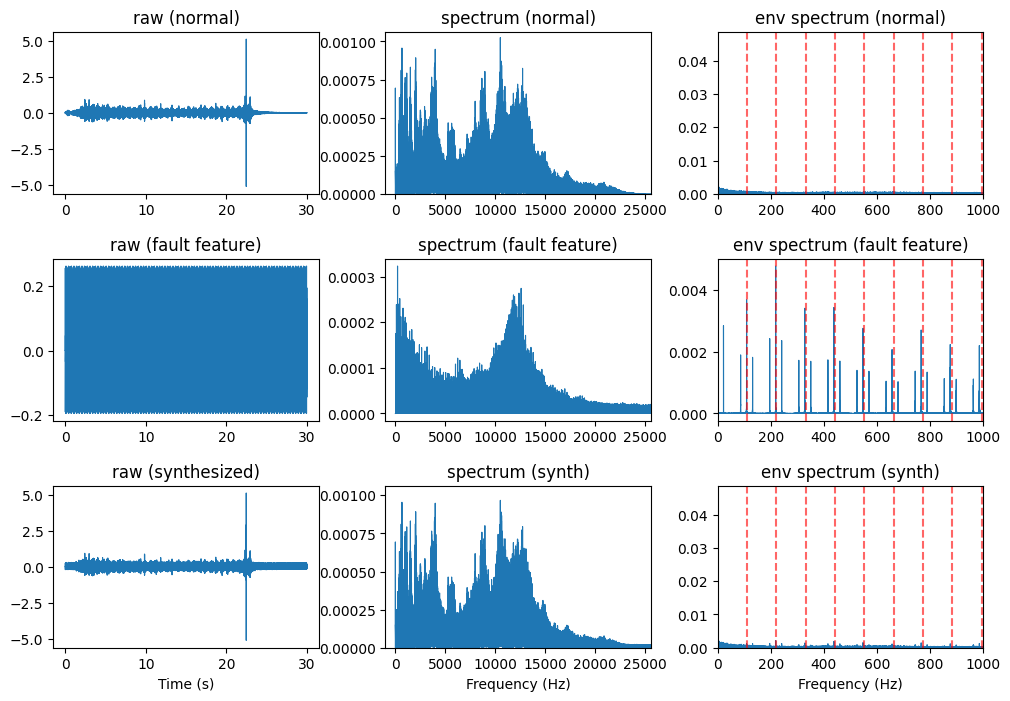

In [10]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'raw (normal)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)')
plot_raw(axs[6], t, x_fault_signal, 'raw (synthesized)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
env = np.abs(hilbert(x_fault_signal))
ymax = 1.1*np.max(fft_simple(env-np.mean(env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'env spectrum (normal)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(x_fault_feature)), fs, 'env spectrum (fault feature)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'env spectrum (synth)', harmonic_lines, xlim=xlim, ylim=ymax)

axs[6].set_xlabel('Time (s)')
axs[7].set_xlabel('Frequency (Hz)')
axs[8].set_xlabel('Frequency (Hz)')
# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


# Kurtogram and Envelope Analysis w/ Band-pass Filtering

In [11]:
nlevel = config['nlevel']
Kwav_norm, Level_w_norm, freq_w_norm, c_norm, maxK_norm, bw_norm, lvl_norm, Wn_norm = kg.fast_kurtogram(x_normal, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal, Level_w_fault_signal, freq_w_fault_signal, c_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, Wn_fault_signal = kg.fast_kurtogram(x_fault_signal, fs, nlevel=nlevel)
f_e_n, A_e_n, env_n, xf_n = envelope_spectrum_band(x_normal, fs, Wn_norm)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s, A_e_s, env_s, xf_s = envelope_spectrum_band(x_fault_signal, fs, Wn_fault_signal)

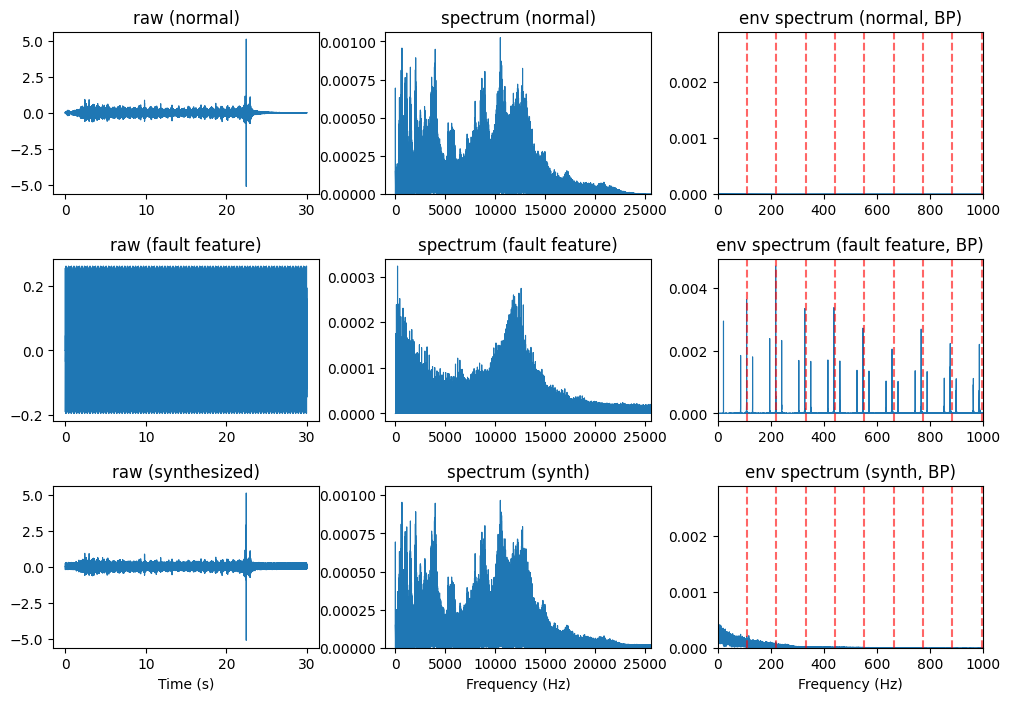

In [12]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'raw (normal)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)')
plot_raw(axs[6], t, x_fault_signal, 'raw (synthesized)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
ymax = 1.1*np.max(fft_simple(env_s-np.mean(env_s), fs)[1])

plot_spectrum(axs[2], env_n, fs, 'env spectrum (normal, BP)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], env_f, fs, 'env spectrum (fault feature, BP)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], env_s, fs, 'env spectrum (synth, BP)', harmonic_lines, xlim=xlim, ylim=ymax)

axs[6].set_xlabel('Time (s)')
axs[7].set_xlabel('Frequency (Hz)')
axs[8].set_xlabel('Frequency (Hz)')


# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


## Normal (Raw & Filtered) vs Fault (Raw & Filtered) 

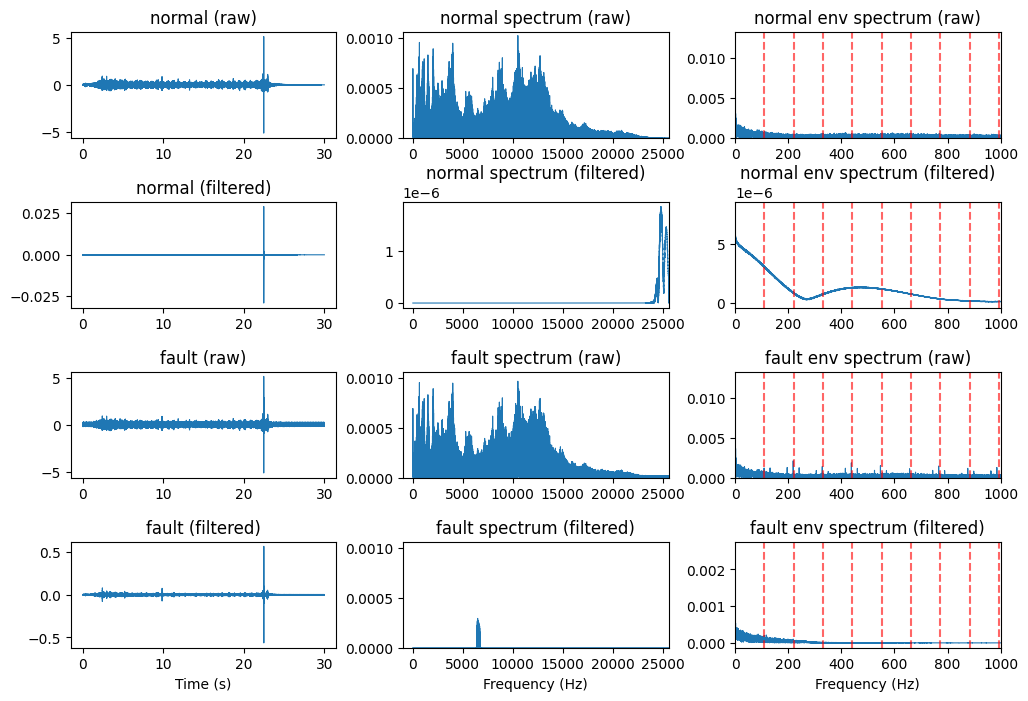

In [13]:
fig, axs = plt.subplots(4, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'normal (raw)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, xf_n, 'normal (filtered)')
plot_raw(axs[6], t, x_fault_signal, 'fault (raw)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[9], t, xf_s, 'fault (filtered)')

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'normal spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], xf_n, fs, 'normal spectrum (filtered)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'fault spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[10], xf_s, fs, 'fault spectrum (filtered)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
x_fault_env = np.abs(hilbert(x_fault_signal))
ymax = 0.3*np.max(fft_simple(x_fault_env-np.mean(x_fault_env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'normal env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(xf_n)), fs, 'normal env spectrum (filtered)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'fault env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[11], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim)


axs[9].set_xlabel('Time (s)')
axs[10].set_xlabel('Frequency (Hz)')
axs[11].set_xlabel('Frequency (Hz)')

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.6, wspace=0.25)
plt.show()


# Feature Visualization

### Kurtogram

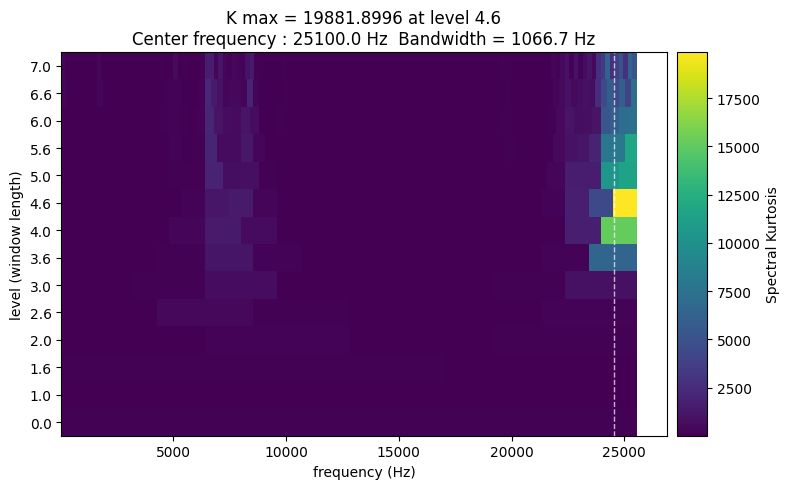

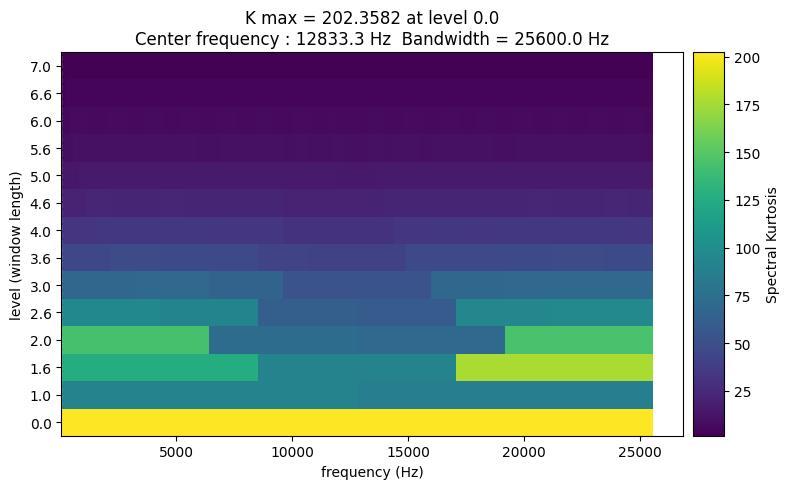

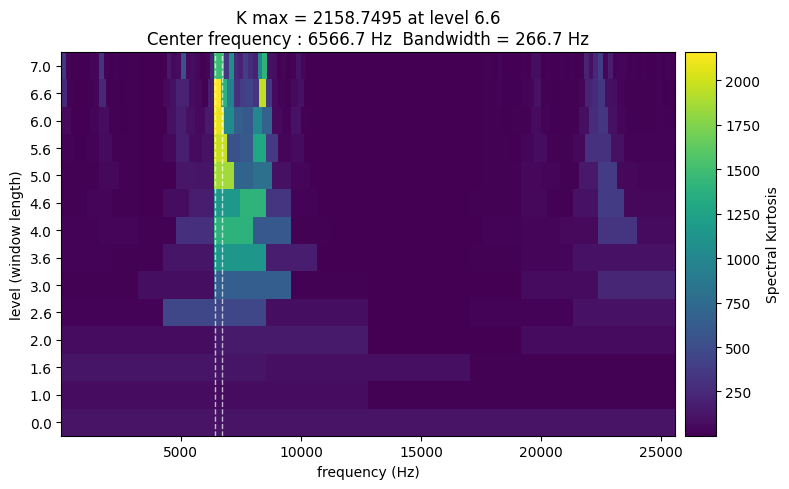

In [14]:
# Show kurtograms (optional visual)
kg.plot_kurtogram(Kwav_norm, Level_w_norm, maxK_norm, bw_norm, lvl_norm, fs, Wn_norm)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal, Level_w_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, fs, Wn_fault_signal)

### Envelope Spectrum

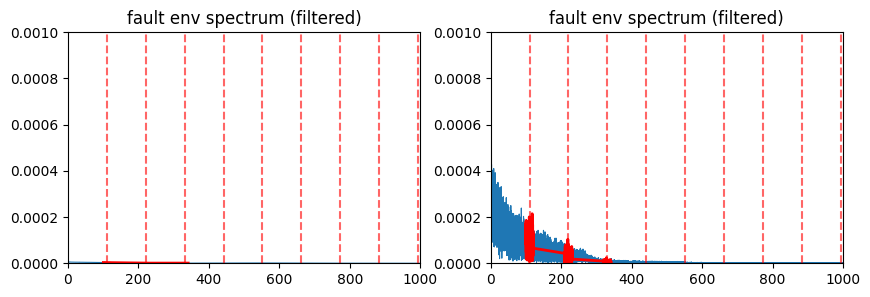

In [15]:
f, A = fft_simple(xf_n-np.mean(xf_n), fs)

f_range = 10
harmonics = np.arange(1, 4)
idx_range = [
    np.where((f >= k*fault_freq - f_range) & (f <= k*fault_freq + f_range))[0]
    for k in harmonics
]
idx_range = np.concatenate(idx_range)
    
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

env = np.abs(hilbert(xf_n))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[0], np.abs(hilbert(xf_n)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[0].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

env = np.abs(hilbert(xf_s))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[1], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[1].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

### Cepstrum

In [16]:
1/fault_freq

np.float64(0.009056501757231685)

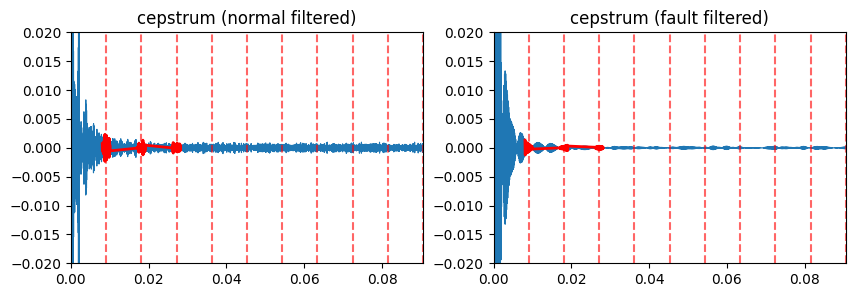

In [17]:
# cep_n = real_cepstrum(x_normal-np.mean(x_normal))
# cep_f = real_cepstrum(x_fault_signal-np.mean(x_fault_signal))
# cep_x = np.arange(len(cep_n)) / fs

cep_n = real_cepstrum(xf_n-np.mean(xf_n))
cep_f = real_cepstrum(xf_s-np.mean(xf_s))
cep_x = np.arange(len(cep_n)) / fs

vlines = [h for h in five_harmonics(1/fault_freq, n=10) if h <= 1000]

t_range = 0.001
harmonics = np.arange(1, 4)
idx_range = [
    np.where((cep_x >= k/(fault_freq) - t_range) & (cep_x <= k/(fault_freq) + t_range))[0]
    for k in harmonics
]
idx_range = np.concatenate(idx_range)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

plot_cepstrum(ax[0], cep_x, cep_n, title='cepstrum (normal filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[0].plot(cep_x[idx_range], cep_n[idx_range], color='r', linewidth=2)

plot_cepstrum(ax[1], cep_x, cep_f, title='cepstrum (fault filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[1].plot(cep_x[idx_range], cep_f[idx_range], color='r', linewidth=2)

# Feature Calculation from each Segment

In [18]:
S = config['segments']
L = N//S

def segments(x):
    return x[:S*L].reshape(S, L)

seg_n = segments(x_normal)
seg_f = segments(x_fault_signal)

print(f'The number of segments: {S}, segment length: {L} samples ({L/fs:.3f} sec)')

The number of segments: 50, segment length: 30720 samples (0.600 sec)


In [19]:
import importlib
import utils.utils_processing as up
importlib.reload(up)

from utils.utils_processing import def_features

In [20]:
nlevel_seg = config['nlevel_seg']

feat_n = []
for v in seg_n:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_n.append(feat)
feat_n = np.array(feat_n)

feat_f = []
for v in seg_f:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_f.append(feat)
feat_f = np.array(feat_f)

c:\Users\AISA3\workspace\Train-1\Python_code_simulation_1\utils\utils_processing.py:112: RuntimeWarning: divide by zero encountered in log
  ceps = np.fft.ifft(np.log(np.abs(spectrum))).real
c:\Users\AISA3\workspace\Train-1\Python_code_simulation_1\utils\utils_processing.py:168: RuntimeWarning: invalid value encountered in scalar divide
  cep_filtered = np.max(cep_signal[idx_t_range])/np.sqrt(np.mean(cep_signal[idx_t_range]**2))
c:\Users\AISA3\workspace\Train-1\Python_code_simulation_1\utils\utils_processing.py:153: RuntimeWarning: invalid value encountered in scalar divide
  cep = np.max(cep_signal[idx_t_range])/np.sqrt(np.mean(cep_signal[idx_t_range]**2))


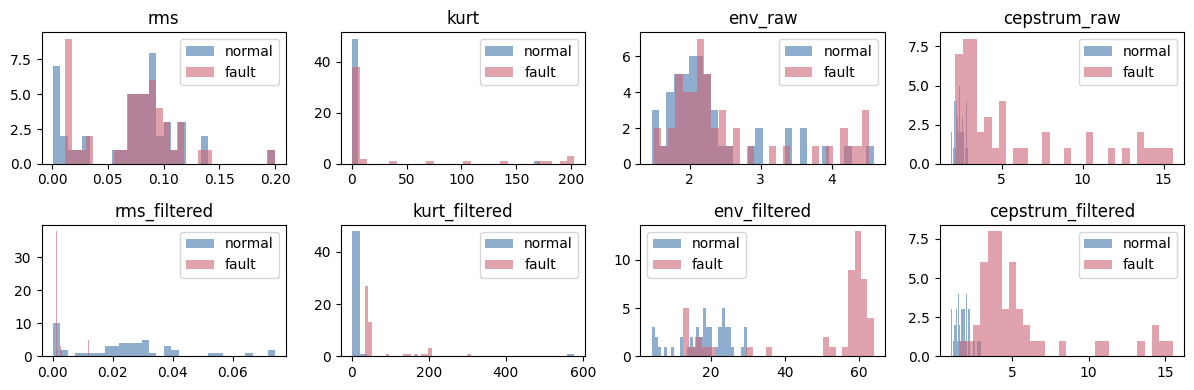

In [21]:
fig, axs = plt.subplots(2, 4, figsize=(12, 4))
axs = axs.ravel()

for i in range(8):
    axs[i].hist(feat_n[:, i], bins=30, color='#4477AA', alpha=0.6, label='normal')
    axs[i].hist(feat_f[:, i], bins=30, color='#CC6677', alpha=0.6, label='fault')
    title = feat_names[i] if 'feat_names' in globals() and i < len(feat_names) else f'feature {i+1}'
    axs[i].set_title(title)
    axs[i].legend()

plt.tight_layout()
plt.show()


In [27]:
print("feat_n shape:", np.asarray(feat_n).shape)
print("feat_f[1] shape:", np.asarray(feat_f[1]).shape)


feat_n shape: (50, 8)
feat_f[1] shape: (8,)


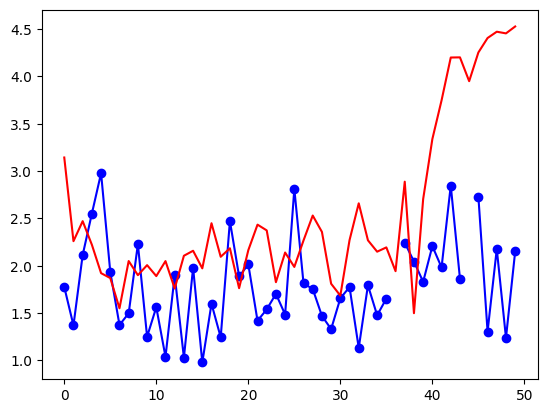

In [40]:
plt.figure()
plt.plot(feat_n[:,7],'b-o')
plt.plot(feat_f[:,2],'r')

정상 >= 결함 - tol 인덱스: []
개수: 0


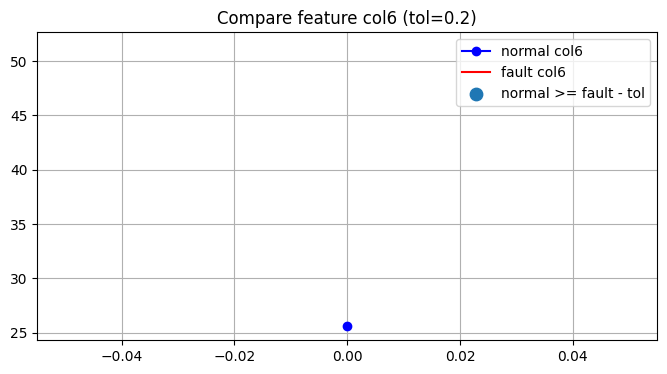

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def find_points_normal_ge_fault(feat_n_2d, feat_f_1d_or_2d, col, tol=0.2, max_len=None):
    """
    feat_n_2d: (N, F)  정상 (예: 50x8)
    feat_f_1d_or_2d: (F,) 또는 (M,F)  결함
    col: 비교할 feature column index
    tol: '비슷한 정도' 허용치. normal >= fault - tol 이면 True
    max_len: 비교 구간 길이 제한(예: 50). None이면 가능한 길이만큼.
    """
    n = np.asarray(feat_n_2d)
    f = np.asarray(feat_f_1d_or_2d)

    # 결함이 (F,) 한 샘플이면 -> (1,F)
    if f.ndim == 1:
        f = f.reshape(1, -1)

    # 길이 맞추기: 둘 다 시간축이 있는 경우 (N vs M)
    N = n.shape[0]
    M = f.shape[0]
    L = min(N, M)
    if max_len is not None:
        L = min(L, max_len)

    n_seq = n[:L, col]
    f_seq = f[:L, col] if M > 1 else np.full(L, f[0, col])  # 결함이 1샘플이면 수평 기준

    # 조건: 정상 >= 결함 - tol  (즉, 정상 >= 결함보다 약간 작아도 OK)
    mask = n_seq >= (f_seq - tol)
    idx = np.where(mask)[0]

    return n_seq, f_seq, idx, mask

# =========================
# 사용 예시
# =========================
col = 7      # 비교할 feature 컬럼 (0~7)
tol = 0.2    # "비슷한 정도" 허용치 (데이터 스케일에 맞게 조절)

n_seq, f_seq, idx, mask = find_points_normal_ge_fault(
    feat_n_2d=feat_n,         # (50,8)
    feat_f_1d_or_2d=feat_f[1],# (8,) 또는 (50,8)
    col=col,
    tol=tol,
    max_len=50
)

print("정상 >= 결함 - tol 인덱스:", idx.tolist())
print("개수:", len(idx))

# =========================
# Plot + 조건 만족 지점 표시
# =========================
plt.figure(figsize=(8,4))
plt.plot(n_seq, 'b-o', label=f'normal col{col}')
plt.plot(f_seq, 'r-',  label=f'fault col{col}')

# 조건 만족 지점(정상 >= 결함 - tol)을 표시
plt.scatter(idx, n_seq[idx], marker='o', s=80, label='normal >= fault - tol')

plt.title(f'Compare feature col{col} (tol={tol})')
plt.grid(True)
plt.legend()
plt.show()


Text(0, 0.5, 'cepstrum_filtered')

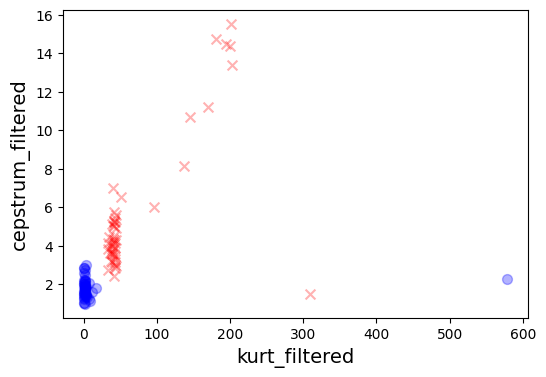

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

n1, n2 = 5, 7  
ax.scatter(feat_n[:, n1], feat_n[:, n2], c='blue', marker='o', s=50, label='Normal', alpha=0.3)
ax.scatter(feat_f[:, n1], feat_f[:, n2], c='red', marker='x', s=50, label='Fault', alpha=0.3)
ax.set_xlabel(feat_names[n1], fontsize=14)
ax.set_ylabel(feat_names[n2], fontsize=14)

# One-Class SVM (1-class SVM) anomaly detection using feat_n

In [23]:
# ; visualize on features 5 and 6
from sklearn.svm import OneClassSVM
from matplotlib.colors import TwoSlopeNorm

# feature indices to visualize (0-based). If you expect 1-based, change accordingly.
n1, n2 = 5, 7

########################################################
# Train One-Class SVM on all features (used for scoring)
########################################################
model_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model_svm.fit(feat_n)

########################################################
# Test One-Class SVM on all features 
########################################################
mask = ~np.isnan(feat_f).any(axis=1) & ~np.isinf(feat_f).any(axis=1)
feat_f_clean = feat_f[mask]

pred = model_svm.predict(feat_f_clean)
out_idx = np.where(pred == -1)[0]


print(out_idx)
print(f'Detected {len(out_idx)} out of {len(feat_f)} faulty segments as anomalies.')

ValueError: Input X contains NaN.
OneClassSVM does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Visualize SVM Decision Boundary

In [ ]:
def check_nan(name, A):
    A = np.asarray(A)
    n_nan = np.isnan(A).sum()
    n_inf = np.isinf(A).sum()
    print(f"{name}: shape={A.shape}, NaN={n_nan}, Inf={n_inf}")

# check_nan("X2d", X2d)
# check_nan("feat_f", feat_f)


In [ ]:
def drop_nonfinite_rows(X, y=None):
    X = np.asarray(X)
    mask = np.isfinite(X).all(axis=1)  # NaN/Inf 없는 행만 True
    Xc = X[mask]
    if y is None:
        return Xc, mask
    yc = np.asarray(y)[mask]
    return Xc, yc, mask


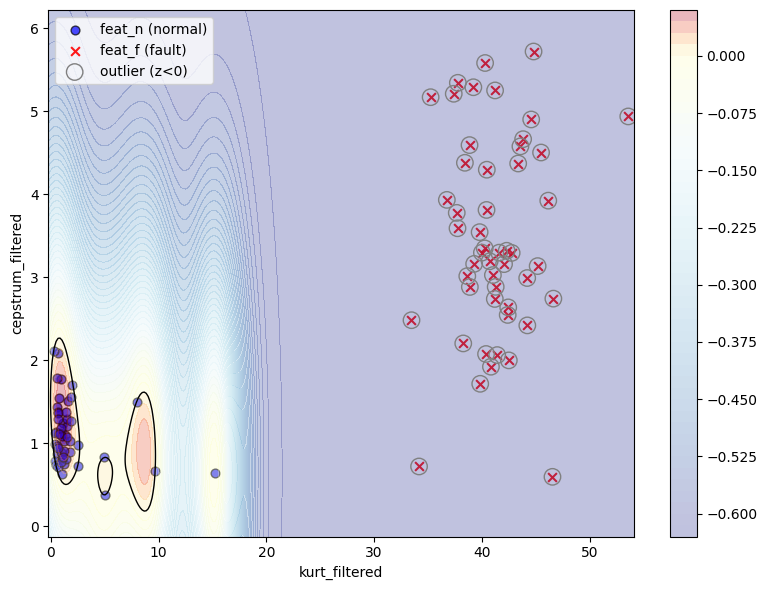

In [ ]:
X2d = feat_n[:, [n1, n2]]
model_svm_2d = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model_svm_2d.fit(X2d)

xx, yy = np.meshgrid(
    np.linspace(np.min(np.vstack([X2d[:,0], feat_f[:, n1]])) - 0.5, np.max(np.vstack([X2d[:,0], feat_f[:, n1]])) + 0.5, 300),
    np.linspace(np.min(np.vstack([X2d[:,1], feat_f[:, n2]])) - 0.5, np.max(np.vstack([X2d[:,1], feat_f[:, n2]])) + 0.5, 300)
)

# (1) 학습 데이터 정리
X2d_clean, mask_n = drop_nonfinite_rows(X2d)
model_svm_2d.fit(X2d_clean)

# (2) mesh 범위 계산에도 반드시 clean 데이터만 사용
Xn0 = X2d_clean[:, 0]
Xn1 = X2d_clean[:, 1]

feat_f2d = np.c_[feat_f[:, n1], feat_f[:, n2]]
feat_f2d_clean, mask_f = drop_nonfinite_rows(feat_f2d)

all0 = np.concatenate([Xn0, feat_f2d_clean[:, 0]])
all1 = np.concatenate([Xn1, feat_f2d_clean[:, 1]])

x_min, x_max = np.min(all0) - 0.5, np.max(all0) + 0.5
y_min, y_max = np.min(all1) - 0.5, np.max(all1) + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# (3) decision_function 입력도 finite 보장
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_svm_2d.decision_function(grid).reshape(xx.shape)

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())

# decision function shading (optional subtle background)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(feat_n[:, n1], feat_n[:, n2], c='blue', marker='o', s=40, edgecolor='k', alpha=0.7, label='feat_n (normal)')
ax.scatter(feat_f[:, n1], feat_f[:, n2], c='red', marker='x', s=40, alpha=0.9, label='feat_f (fault)')
cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r',norm=norm, alpha=0.3) # Anomaly score (<0: outlier, >0: inlier)
cbar = fig.colorbar(cf, ax=ax)
ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1) # Decision boundary
ax.scatter(feat_f[out_idx, n1], feat_f[out_idx, n2], facecolors='none', edgecolors='gray', s=140, linewidths=1, label='outlier (z<0)')

ax.set_xlabel(feat_names[n1])
ax.set_ylabel(feat_names[n2])
ax.legend(loc='best')
plt.tight_layout()
plt.show()



In [ ]:
# ########################################################
# # Train two-feature SVM for visualization
# ########################################################
# # X2d = feat_n[:, [n1, n2]]
# # model_svm_2d = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
# # model_svm_2d.fit(X2d)

# # xx, yy = np.meshgrid(
# #     np.linspace(np.min(np.vstack([X2d[:,0], feat_f[:, n1]])) - 0.5, np.max(np.vstack([X2d[:,0], feat_f[:, n1]])) + 0.5, 300),
# #     np.linspace(np.min(np.vstack([X2d[:,1], feat_f[:, n2]])) - 0.5, np.max(np.vstack([X2d[:,1], feat_f[:, n2]])) + 0.5, 300)
# # )
# # Z = model_svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
# # Z = Z.reshape(xx.shape)
# norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())

# # decision function shading (optional subtle background)
# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.scatter(feat_n[:, n1], feat_n[:, n2], c='blue', marker='o', s=40, edgecolor='k', alpha=0.7, label='feat_n (normal)')
# ax.scatter(feat_f[:, n1], feat_f[:, n2], c='red', marker='x', s=40, alpha=0.9, label='feat_f (fault)')
# cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r',norm=norm, alpha=0.3) # Anomaly score (<0: outlier, >0: inlier)
# cbar = fig.colorbar(cf, ax=ax)
# ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1) # Decision boundary
# ax.scatter(feat_f[out_idx, n1], feat_f[out_idx, n2], facecolors='none', edgecolors='gray', s=140, linewidths=1, label='outlier (z<0)')

# ax.set_xlabel(feat_names[n1])
# ax.set_ylabel(feat_names[n2])
# ax.legend(loc='best')
# plt.tight_layout()
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from matplotlib.colors import TwoSlopeNorm

# 예: 너가 가진 함수
# drop_nonfinite_rows(X) -> (X_clean, mask)  # mask는 원본에서 남은 행 True/False

# ---------------------------
# 0) 데이터 준비 (예시 변수명)
# ---------------------------
# X_train      : (Ntrain, D)  # 학습용 (정상만 권장)
# X_test_n     : (Nn, D)      # 테스트 정상
# X_test_f     : (Nf, D)      # 테스트 결함

# ---------------------------
# 1) 2D feature 선택 + clean
# ---------------------------
Xtr2d = X_train[:, [n1, n2]]
Xtr2d_clean, _ = drop_nonfinite_rows(Xtr2d)

Xtn2d = X_test_n[:, [n1, n2]]
Xtn2d_clean, mask_tn = drop_nonfinite_rows(Xtn2d)

Xtf2d = X_test_f[:, [n1, n2]]
Xtf2d_clean, mask_tf = drop_nonfinite_rows(Xtf2d)

# ---------------------------
# 2) Train (학습)
# ---------------------------
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(Xtr2d_clean)

# ---------------------------
# 3) Test (판정) -> 색 분류 기준
# ---------------------------
pred_tn = model.predict(Xtn2d_clean)  # +1 inlier, -1 outlier
pred_tf = model.predict(Xtf2d_clean)

# 테스트 정상 중에서도 모델이 outlier로 본 것
tn_in  = (pred_tn ==  1)
tn_out = (pred_tn == -1)

# 테스트 결함 중에서도 모델이 inlier로 본 것(모델이 놓친 결함)
tf_in  = (pred_tf ==  1)
tf_out = (pred_tf == -1)

# ---------------------------
# 4) 경계 시각화용 grid (train + test 범위 기반)
# ---------------------------
all0 = np.concatenate([Xtr2d_clean[:,0], Xtn2d_clean[:,0], Xtf2d_clean[:,0]])
all1 = np.concatenate([Xtr2d_clean[:,1], Xtn2d_clean[:,1], Xtf2d_clean[:,1]])
x_min, x_max = all0.min() - 0.5, all0.max() + 0.5
y_min, y_max = all1.min() - 0.5, all1.max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(grid).reshape(xx.shape)

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())

# ---------------------------
# 5) Plot: "예측 기준" 파랑/빨강으로 표시
# ---------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# 배경 + 경계
cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', norm=norm, alpha=0.25)
fig.colorbar(cf, ax=ax)
ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1)

# (중요) 테스트 데이터들을 "예측 결과"로 색칠
# 예측 정상(inlier) -> 파랑
ax.scatter(Xtn2d_clean[tn_in, 0], Xtn2d_clean[tn_in, 1],
           c='blue', s=40, edgecolor='k', alpha=0.7, label='Test Normal predicted IN')

# 테스트 정상인데 outlier로 나온 것 -> 빨강(오탐)
ax.scatter(Xtn2d_clean[tn_out, 0], Xtn2d_clean[tn_out, 1],
           c='red', marker='x', s=50, alpha=0.9, label='Test Normal predicted OUT (FP)')

# 테스트 결함인데 outlier -> 빨강(정탐)
ax.scatter(Xtf2d_clean[tf_out, 0], Xtf2d_clean[tf_out, 1],
           c='red', marker='x', s=50, alpha=0.9, label='Test Fault predicted OUT')

# 테스트 결함인데 inlier -> 파랑(미탐)
ax.scatter(Xtf2d_clean[tf_in, 0], Xtf2d_clean[tf_in, 1],
           c='blue', facecolors='none', edgecolors='blue', s=80, linewidths=1.5,
           label='Test Fault predicted IN (FN)')

ax.set_xlabel(feat_names[n1])
ax.set_ylabel(feat_names[n2])
ax.legend(loc='best')
plt.tight_layout()
plt.show()


NameError: name 'X_train' is not defined